### Objective: This notebook simulates a 2D dataset to demonstrate two key principles:

1. How a Gaussian Mixture Model (GMM) can be used to generate a probabilistic score for Out-of-Distribution (OOD) detection.
2. How naively applying PCA for dimensionality reduction before OOD detection can be detrimental, as it can "collapse" the OOD data into the in-distribution space, destroying the very information that makes it distinct.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
import matplotlib.transforms as transforms
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import roc_curve, auc
from sklearn.datasets import make_blobs

# Set a consistent style for plots
plt.style.use('seaborn-v0_8-whitegrid')
print("Setup Complete")


Setup Complete


In [2]:
def draw_gmm_ellipses(gmm, ax, gmm_train_data, cmap, norm):
    """Draws the ellipses representing the GMM components, colored by score."""
    for n in range(gmm.n_components):
        if gmm.covariance_type == 'full': covariances = gmm.covariances_[n][:2, :2]
        elif gmm.covariance_type == 'tied': covariances = gmm.covariances_[:2, :2]
        elif gmm.covariance_type == 'diag': covariances = np.diag(gmm.covariances_[n][:2])
        elif gmm.covariance_type == 'spherical': covariances = np.eye(gmm.means_.shape[1]) * gmm.covariances_[n]
        v, w = np.linalg.eigh(covariances)
        u = w[0] / np.linalg.norm(w[0]); angle = np.arctan2(u[1], u[0]); angle = 180 * angle / np.pi
        v = 2. * np.sqrt(2.) * np.sqrt(v)
        
        # Calculate OOD score for the ellipse's center
        center_point = gmm.means_[n].reshape(1, -1)
        score = calculate_ood_score(gmm, center_point, gmm_train_data)
        color = cmap(norm(score[0]))
        
        ell = Ellipse(gmm.means_[n, :2], v[0], v[1], angle=angle, 
                      edgecolor=color, facecolor='none',
                      lw=2.5, ls='--')
        ell.set_clip_box(ax.bbox); ax.add_artist(ell)

def plot_data_with_gmm(gmm, X_id_train, X_id_test, X_ood, title="Data Distribution", feature_names=["Feature 1", "Feature 2"]):
    """Visualizes data distributions with a framed legend and colored ellipses."""
    plt.figure(figsize=(6, 3)); ax = plt.gca()
    cmap = plt.get_cmap('cividis')
    
    scores_train = calculate_ood_score(gmm, X_id_train, X_id_train)
    scores_test = calculate_ood_score(gmm, X_id_test, X_id_train)
    scores_ood = calculate_ood_score(gmm, X_ood, X_id_train)
    
    all_scores = np.concatenate([scores_train, scores_test, scores_ood])
    norm = plt.Normalize(vmin=all_scores.min(), vmax=all_scores.max())
    
    sc = plt.scatter(X_id_test[:, 0], X_id_test[:, 1], c=scores_test, cmap=cmap,  norm=norm, s=30, marker='s', label='ID Test')
    plt.scatter(X_id_train[:, 0], X_id_train[:, 1],  edgecolors=sc.to_rgba(scores_train), facecolors='none', s=30, marker='o', alpha=0.7, label='ID Train')
    plt.scatter(X_ood[:, 0], X_ood[:, 1], c=scores_ood, cmap=cmap, norm=norm, s=40, marker='x', label='OOD')
    
    # MODIFIED: Pass cmap and norm to the ellipse drawing function
    draw_gmm_ellipses(gmm, ax, X_id_train, cmap, norm)
    
    plt.title(title, fontsize=11)
    plt.xlabel(f"{feature_names[0]}", fontsize=10); plt.ylabel(f"{feature_names[1]}", fontsize=10)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=False, ncol=3, frameon=True, edgecolor='gray')
    cbar = plt.colorbar(sc, ax=ax); cbar.set_label('OOD Score Intensity', rotation=270, labelpad=15, fontsize=10)
    ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False); ax.grid(False)
    plt.axis('equal'); plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.show()

def calculate_ood_score(model, data_to_score, train_data):
    """
    Calculates a normalized NLL-based OOD score between 0 and 1.
    The score is normalized based on the range of NLL values in the training data.
    """
    # Get NLL values for the training data to establish a baseline range
    train_nll = -model.score_samples(train_data)
    
    # Find the min and max NLL from the training data for normalization
    nll_min = np.min(train_nll)  # The NLL of the "most normal" training point
    nll_max = np.max(train_nll)  # The NLL of the "least normal" training point (outlier)
    
    # Calculate the NLL for the new data we want to score
    data_nll = -model.score_samples(data_to_score)
    
    # Normalize the score based on the training data's range
    # Add a small epsilon to avoid division by zero in edge cases
    score = (data_nll - nll_min) / ((nll_max - nll_min) + 1e-9)
    
    # Clip the score to the [0, 1] range. Points more normal than the training
    # set get 0, and points more abnormal get 1.
    return np.clip(score, 0, 1)

In [3]:
# --- Generate Sample Data ---
# In-distribution data (2 clusters)
X_id_train, _ = make_blobs(n_samples=500, centers=[[0, 0], [2, -2]], cluster_std=1.0, random_state=42)
X_id_test, _ = make_blobs(n_samples=500, centers=[[0, 0], [2, -2]], cluster_std=1.0, random_state=24)

# MODIFIED: Changed the starting point to create initial overlap
initial_ood_center = np.array([[0, 0]])
shift_vector = np.array([1, .3]) 

print("Helper Functions and Sample Data Defined")

Helper Functions and Sample Data Defined


### Simulation - GMM on Full 2D Data
This is the core of our first experiment. We will fit a GMM on 2D synthetically-generated data and then see how the AUROC score changes as we recursively shift the OOD data further away.

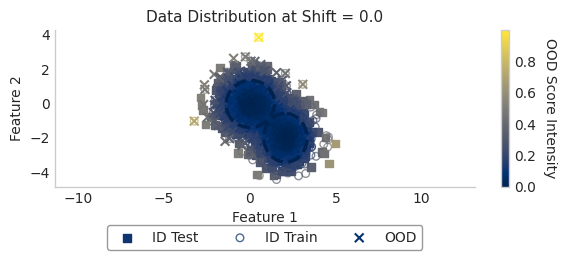

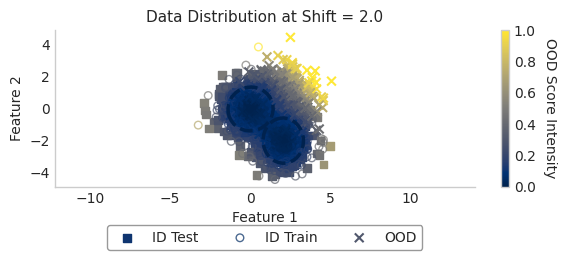

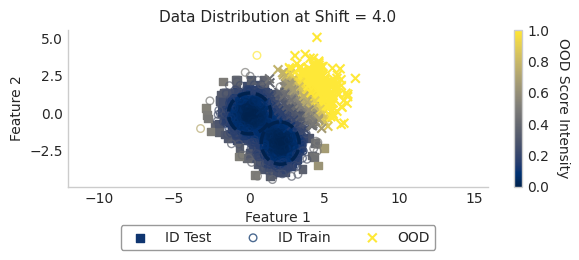

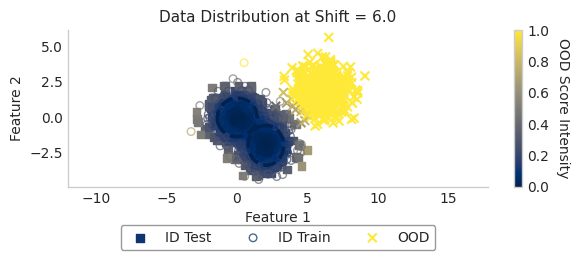

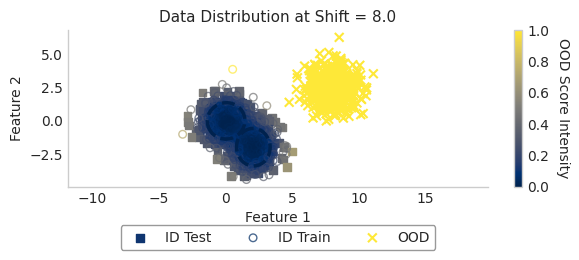

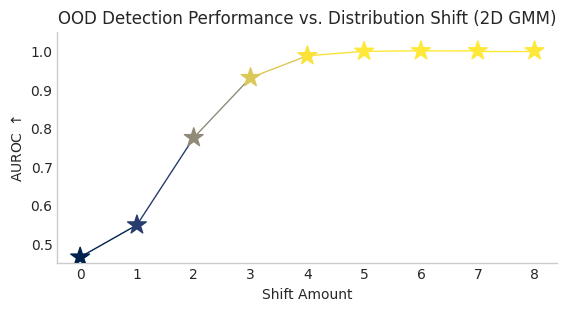

In [4]:
# --- Fit GMM and run simulation (Code from previous step, collapsed for brevity) ---
gmm_2d = GaussianMixture(n_components=2, random_state=42).fit(X_id_train)
auroc_results_2d = []; shifts = np.linspace(0, 8, 9)
for i, shift in enumerate(shifts):
    X_ood_current = make_blobs(n_samples=500, centers=initial_ood_center + shift * shift_vector, cluster_std=1.0, random_state=42)[0]
    if i % 2 == 0: # Plot fewer steps to speed up
        plot_data_with_gmm(gmm_2d, X_id_train, X_id_test, X_ood_current, f"Data Distribution at Shift = {shift:.1f}")
    scores_id = calculate_ood_score(gmm_2d, X_id_test, X_id_train); scores_ood = calculate_ood_score(gmm_2d, X_ood_current, X_id_train)
    y_true = np.concatenate([np.zeros(len(scores_id)), np.ones(len(scores_ood))]); y_scores = np.concatenate([scores_id, scores_ood])
    fpr, tpr, _ = roc_curve(y_true, y_scores); auroc = auc(fpr, tpr); auroc_results_2d.append(auroc)

# --- Plot the final AUROC results (Code from previous step) ---
plt.figure(figsize=(6.45, 3)); ax = plt.gca()
plt.rcParams["text.latex.preamble"] += (r"\usepackage{amsmath} \usepackage{amsfonts} \usepackage{bm}")
cmap = plt.get_cmap('cividis'); norm = plt.Normalize(vmin=min(auroc_results_2d), vmax=max(auroc_results_2d))
for i in range(len(shifts) - 1):
    plt.plot(shifts[i:i+2], auroc_results_2d[i:i+2], color=cmap(norm(auroc_results_2d[i])), linestyle='-', linewidth=1)
plt.scatter(shifts, auroc_results_2d, c=auroc_results_2d, cmap=cmap, norm=norm, marker='*', s=200, zorder=3)
plt.grid(False); ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)
plt.title("OOD Detection Performance vs. Distribution Shift (2D GMM)"); plt.xlabel("Shift Amount")
ylabel_text = r'AUROC $\uparrow$' 
plt.ylabel(ylabel_text); plt.ylim(0.45, 1.05); plt.show()

### The PCA Comparison: Demonstrating the Feature Collapse
Now, we'll repeat the process, but this time we will first apply PCA. We will fit PCA only on the ID training data and then use it to transform all other data, showing how it can discard crucial information. We will show the original 2D data and literally draw the line representing the first principal component, showing how the OOD points "collapse" onto it.

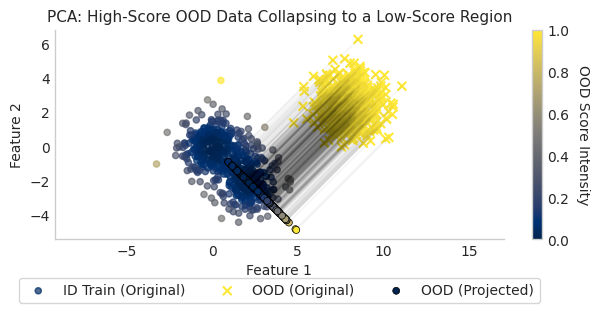

In [5]:
def plot_pca_collapse(pca, gmm, X_id_train, X_ood_final, feature_names=["Feature 1", "Feature 2"]):
    """Visualizes how PCA collapses high-score OOD data into a low-score region."""
    plt.figure(figsize=(6.5, 3.5)); ax = plt.gca()
    cmap = plt.get_cmap('cividis')

    # Project OOD data onto the PCA line
    X_ood_projected = pca.inverse_transform(pca.transform(X_ood_final))
    
    # Calculate scores for all three sets of points
    scores_id = calculate_ood_score(gmm, X_id_train, X_id_train)
    scores_ood = calculate_ood_score(gmm, X_ood_final, X_id_train)
    scores_ood_projected = calculate_ood_score(gmm, X_ood_projected, X_id_train)
    
    # Normalize colors based on the full range of scores
    all_scores = np.concatenate([scores_id, scores_ood, scores_ood_projected])
    norm = plt.Normalize(vmin=all_scores.min(), vmax=all_scores.max())

    # Plot original ID data (mostly dark)
    plt.scatter(X_id_train[:, 0], X_id_train[:, 1], c=scores_id, cmap=cmap, norm=norm, s=20, alpha=0.7, label='ID Train (Original)')
    
    # Plot original OOD data (bright)
    sc = plt.scatter(X_ood_final[:, 0], X_ood_final[:, 1], c=scores_ood, cmap=cmap, norm=norm, s=40, marker='x', label='OOD (Original)')
    
    # Plot projected OOD data (now dark)
    plt.scatter(X_ood_projected[:, 0], X_ood_projected[:, 1], c=scores_ood_projected, cmap=cmap, norm=norm, marker='o', s=25, edgecolor='black', linewidth=0.5, label='OOD (Projected)', zorder=3)

    # Draw projection lines
    for i in range(len(X_ood_final)):
        plt.plot([X_ood_final[i, 0], X_ood_projected[i, 0]], [X_ood_final[i, 1], X_ood_projected[i, 1]], 'k-', alpha=0.03)

    plt.title("PCA: High-Score OOD Data Collapsing to a Low-Score Region", fontsize=11)
    plt.xlabel(f"{feature_names[0]}", fontsize=10); plt.ylabel(f"{feature_names[1]}", fontsize=10)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, ncol=3, frameon=True)
    cbar = plt.colorbar(sc, ax=ax); cbar.set_label('OOD Score Intensity', rotation=270, labelpad=15, fontsize=10)
    ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False); ax.grid(False)
    plt.axis('equal'); plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.show()

# --- 1. Fit PCA ONLY on the ID training data ---
pca = PCA(n_components=1, random_state=42).fit(X_id_train)

# --- 2. Take the most separated OOD data ---
X_ood_final = make_blobs(n_samples=500, centers=initial_ood_center + shifts[-1] * shift_vector, cluster_std=1.0, random_state=42)[0]

# --- 3. Visualize the PCA "Collapse" ---
plot_pca_collapse(pca, gmm_2d, X_id_train, X_ood_final)

### Run the Simulation on 1D PCA-Transformed Data
Now we see the consequence of this collapse on our OOD detection score.

--- Starting 2D GMM Simulation ---
2D Simulation Complete.

--- Starting 1D PCA-based GMM Simulation ---
1D Simulation Complete.


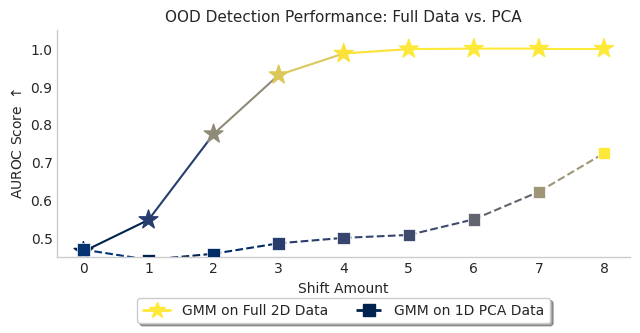

In [6]:
# --- 2D GMM Simulation (Full Data) ---
print("--- Starting 2D GMM Simulation ---")
gmm_2d = GaussianMixture(n_components=2, random_state=42).fit(X_id_train)
auroc_results_2d = []
shifts = np.linspace(0, 8, 9)
for shift in shifts:
    X_ood_current = make_blobs(n_samples=500, centers=initial_ood_center + shift * shift_vector, cluster_std=1.0, random_state=42)[0]
    scores_id = calculate_ood_score(gmm_2d, X_id_test, X_id_train)
    scores_ood = calculate_ood_score(gmm_2d, X_ood_current, X_id_train)
    y_true = np.concatenate([np.zeros(len(scores_id)), np.ones(len(scores_ood))])
    y_scores = np.concatenate([scores_id, scores_ood])
    auroc = auc(*roc_curve(y_true, y_scores)[:2])
    auroc_results_2d.append(auroc)
print("2D Simulation Complete.")

# --- 1D PCA-based GMM Simulation ---
print("\n--- Starting 1D PCA-based GMM Simulation ---")
pca = PCA(n_components=1, random_state=42).fit(X_id_train)
X_id_train_pca = pca.transform(X_id_train)
X_id_test_pca = pca.transform(X_id_test)
gmm_1d = GaussianMixture(n_components=2, random_state=42).fit(X_id_train_pca)
auroc_results_1d = []
for shift in shifts:
    X_ood_current = make_blobs(n_samples=500, centers=initial_ood_center + shift * shift_vector, cluster_std=1.0, random_state=42)[0]
    X_ood_current_pca = pca.transform(X_ood_current)
    scores_id_pca = calculate_ood_score(gmm_1d, X_id_test_pca, X_id_train_pca)
    scores_ood_pca = calculate_ood_score(gmm_1d, X_ood_current_pca, X_id_train_pca)
    y_true = np.concatenate([np.zeros(len(scores_id_pca)), np.ones(len(scores_ood_pca))])
    y_scores = np.concatenate([scores_id_pca, scores_ood_pca])
    auroc = auc(*roc_curve(y_true, y_scores)[:2])
    auroc_results_1d.append(auroc)
print("1D Simulation Complete.")


# --- NEW: Final Comparison Plotting Function ---
def plot_auroc_comparison(shifts, auroc_2d, auroc_1d):
    """
    Plots a styled comparison of AUROC scores for 2D vs 1D data.
    """
    plt.figure(figsize=(6.5, 3.5)); ax = plt.gca()
    cmap = plt.get_cmap('cividis')

    # --- Plot the 2D Data Results (Stars) ---
    norm_2d = plt.Normalize(vmin=min(auroc_2d), vmax=max(auroc_2d))
    for i in range(len(shifts) - 1):
        plt.plot(shifts[i:i+2], auroc_2d[i:i+2], color=cmap(norm_2d(auroc_2d[i])), ls='-')
    plt.scatter(shifts, auroc_2d, c=auroc_2d, cmap=cmap, norm=norm_2d, marker='*', s=200, zorder=3)

    # --- Plot the 1D PCA Data Results (Squares) ---
    norm_1d = plt.Normalize(vmin=min(auroc_1d), vmax=max(auroc_1d))
    for i in range(len(shifts) - 1):
        plt.plot(shifts[i:i+2], auroc_1d[i:i+2], color=cmap(norm_1d(auroc_1d[i])), ls='--', label='GMM on 1D PCA Data')
    plt.scatter(shifts, auroc_1d, c=auroc_1d, cmap=cmap, norm=norm_1d, marker='s', s=80, zorder=3, label='GMM on 1D PCA Data',
                edgecolor='white', linewidth=0.5)

    # --- Styling and Custom Legend ---
    ax.grid(False)
    ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)
    plt.title("OOD Detection Performance: Full Data vs. PCA", fontsize=11)
    plt.xlabel("Shift Amount", fontsize=10)
    plt.rcParams["text.latex.preamble"] += (r"\usepackage{amsmath} \usepackage{amsfonts} \usepackage{bm}")
    ylabel_text = r'AUROC Score $\uparrow$' 
    plt.ylabel(ylabel_text, fontsize=10)
    plt.ylim(0.45, 1.05)

    # Create custom legend handles because the lines are multi-colored
    legend_handles = [
        Line2D([0], [0], color=cmap.colors[-1], lw=2, ls='-', marker='*', markersize=12, label='GMM on Full 2D Data'),
        Line2D([0], [0], color=cmap.colors[0], lw=2, ls='--', marker='s', markersize=8, label='GMM on 1D PCA Data')
    ]
    ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, frameon=True, ncols=2)
     
    plt.tight_layout()
    plt.show()

# --- Plot the final comparison ---
plot_auroc_comparison(shifts, auroc_results_2d, auroc_results_1d)

### Synthetic Data (Arctique) - GMM on Full 2D Data
We repeat the analysis using two positively/negatively correlated features from uncertainty maps of synthetic data mimicking H&E-stained regions of a lizard’s colon, and evaluate how the AUROC score changes under different OOD distribution shifts.

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()
LAB_PATH = os.getenv('LAB_PATH')

base_path = LAB_PATH + 'vguarin/aggrigator_experiments/output/tables/'
# id_filename = 'aggregation_value_summary_joint_noise_arctique_semantic_blood_cells_dropout_pu_0_00.csv'
id_filename = 'spatial_fingerprint_arctique_instance_nuclei_intensity_0_00_dropout_pu.csv'
ood_filenames = {
    # 0.25: 'aggregation_value_summary_joint_noise_arctique_semantic_blood_cells_dropout_pu_0_25.csv',
    0.50: 'spatial_fingerprint_arctique_instance_nuclei_intensity_0_50_dropout_pu.csv',
    # 0.50: 'aggregation_value_summary_joint_noise_arctique_semantic_blood_cells_dropout_pu_0_50.csv',
    # 0.75: 'aggregation_value_summary_joint_noise_arctique_semantic_blood_cells_dropout_pu_0_75.csv',
    1.00: 'spatial_fingerprint_arctique_instance_nuclei_intensity_1_00_dropout_pu.csv',
    # 1.00: 'aggregation_value_summary_joint_noise_arctique_semantic_blood_cells_dropout_pu_1_00.csv'
}
feature_columns = ["moran", "eds"]
# feature_columns = ["class_mean_w_equal_weights_configurable_{'include_background': False, 'ignore_index': 0}", 'above_quantile_mean_fg_ratio']
# feature_columns = ["class_mean_weighted_by_occurrence_configurable_{'include_background': False, 'ignore_index': 0}", 'above_quantile_mean_fg_ratio']
short_feature_names = ["Morans'I", "EDS"]
# short_feature_names = ["Equally weighted class mean", "Above quantile fg. ratio"]
noise_levels = [0.00] + sorted(ood_filenames.keys())


Loaded and scaled ID data. Training size: 45, Test size: 5
Loaded and scaled OOD data for noise level 0.5. Size: 50
Loaded and scaled OOD data for noise level 1.0. Size: 50

--- Generating GMM plots for each noise level ---


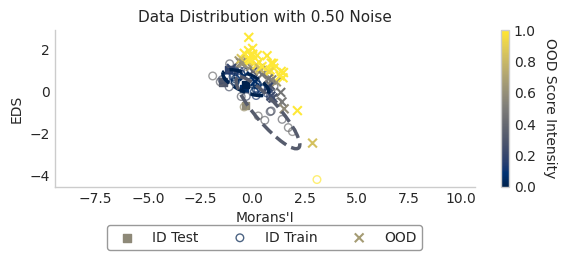

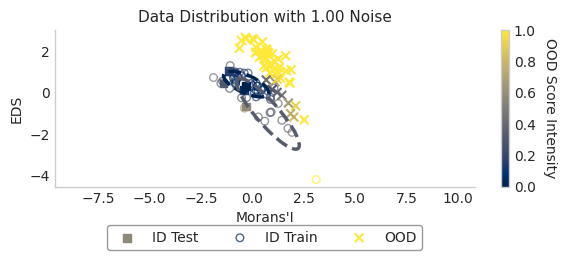


--- Calculating AUROC scores ---

--- Generating final AUROC performance plot ---


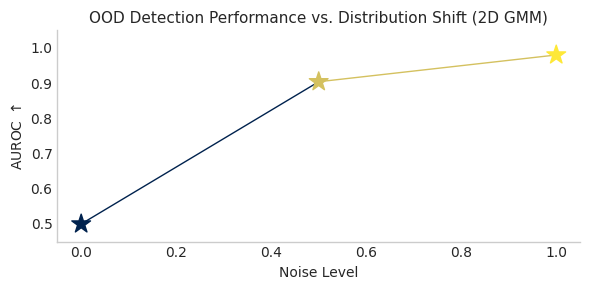

In [18]:
try:
    # --- Load, split, and scale data ---
    id_data_raw = pd.read_csv(base_path + id_filename)[feature_columns].values
    X_id_train_raw, X_id_test_raw = train_test_split(id_data_raw, test_size=0.1, random_state=42)
    scaler = StandardScaler().fit(X_id_train_raw)
    X_id_train = scaler.transform(X_id_train_raw)
    X_id_test = scaler.transform(X_id_test_raw)
    print(f"Loaded and scaled ID data. Training size: {len(X_id_train)}, Test size: {len(X_id_test)}")
    ood_data = {}
    for level, fname in ood_filenames.items():
        ood_raw = pd.read_csv(base_path + fname)[feature_columns].values
        ood_data[level] = scaler.transform(ood_raw)
        print(f"Loaded and scaled OOD data for noise level {level}. Size: {len(ood_data[level])}")

    # --- Fit GMM and generate distribution plots ---
    gmm_2d = GaussianMixture(n_components=2, random_state=42, reg_covar=1e-6).fit(X_id_train)
    print("\n--- Generating GMM plots for each noise level ---")
    for noise_level, ood_set in ood_data.items():
        plot_data_with_gmm(
            gmm_2d, X_id_train, X_id_test, ood_set,
            title=f"Data Distribution with {noise_level:.2f} Noise",
            feature_names=short_feature_names
        )

    # --- ADDED: Calculate AUROC scores for each noise level ---
    print("\n--- Calculating AUROC scores ---")
    auroc_results_2d = []
    # The list of datasets to evaluate against, starting with the ID test set
    ood_sets_for_eval = [X_id_test] + [ood_data[level] for level in sorted(ood_data.keys())]
    for d in ood_sets_for_eval:
        scores_id = calculate_ood_score(gmm_2d, X_id_test, X_id_train)
        scores_ood = calculate_ood_score(gmm_2d, d, X_id_train)
        y_true = np.concatenate([np.zeros(len(scores_id)), np.ones(len(scores_ood))])
        y_scores = np.concatenate([scores_id, scores_ood])
        auroc = auc(*roc_curve(y_true, y_scores)[:2])
        auroc_results_2d.append(auroc)
    # print("AUROC Scores:", auroc_results_2d)

    # --- ADDED: Plot the final AUROC results ---
    print("\n--- Generating final AUROC performance plot ---")
    plt.figure(figsize=(6, 3)); ax = plt.gca()
    cmap = plt.get_cmap('cividis')
    norm = plt.Normalize(vmin=min(auroc_results_2d), vmax=max(auroc_results_2d))
    for i in range(len(noise_levels) - 1):
        plt.plot(noise_levels[i:i+2], auroc_results_2d[i:i+2],
                 color=cmap(norm(auroc_results_2d[i])),
                 linestyle='-', linewidth=1)
    plt.scatter(noise_levels, auroc_results_2d, c=auroc_results_2d, cmap=cmap, norm=norm, marker='*', s=200, zorder=3)
    plt.rcParams["text.latex.preamble"] += (r"\usepackage{amsmath} \usepackage{amsfonts} \usepackage{bm}")
    plt.grid(False); ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)
    plt.title("OOD Detection Performance vs. Distribution Shift (2D GMM)", fontsize=11)
    plt.xlabel("Noise Level", fontsize=10)
    ylabel_text = r'AUROC $\uparrow$' 
    plt.ylabel(ylabel_text, fontsize=10)
    plt.ylim(0.45, 1.05)
    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f"\n--- ERROR ---")
    print(f"Could not find the data file: {e.filename}")
    print("Please ensure the base_path, filenames, and column names are correct.")
except Exception as e:
    print(f"\nAn unexpected error occurred: {e}")

Data loading and preparation complete.

--- Starting 2D GMM Simulation on Real Data ---
2D Simulation Complete. AUROC Scores: [np.float64(0.5), np.float64(0.904), np.float64(0.98)]

--- Visualizing PCA Collapse ---


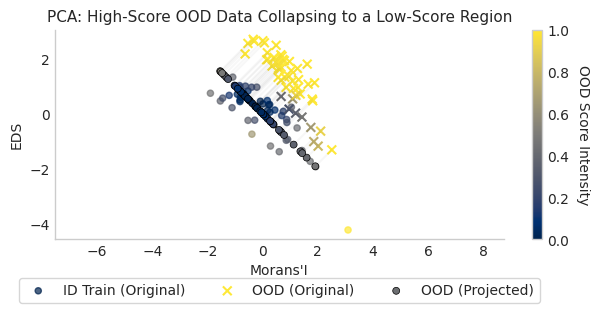


--- Starting 1D PCA-based GMM Simulation ---
1D Simulation Complete. AUROC Scores: [np.float64(0.5), np.float64(0.608), np.float64(0.632)]

--- Generating Final AUROC Comparison Plot ---


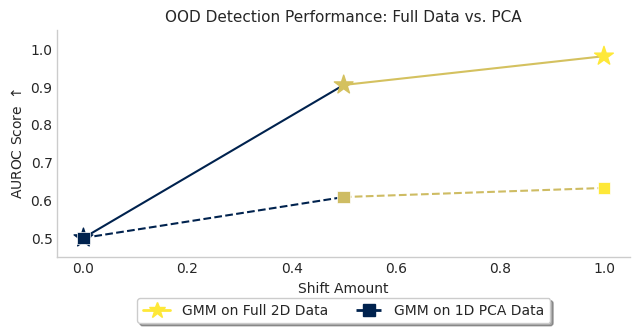

In [19]:
# --- 2. Main Analysis Script ---
try:
    # --- Load, split, and scale data ---
    id_data_raw = pd.read_csv(base_path + id_filename)[feature_columns].values
    X_id_train_raw, X_id_test_raw = train_test_split(id_data_raw, test_size=0.1, random_state=42)
    scaler = StandardScaler().fit(X_id_train_raw)
    X_id_train = scaler.transform(X_id_train_raw)
    X_id_test = scaler.transform(X_id_test_raw)
    ood_data = {}
    for level, fname in ood_filenames.items():
        ood_raw = pd.read_csv(base_path + fname)[feature_columns].values
        ood_data[level] = scaler.transform(ood_raw)
    print("Data loading and preparation complete.")
    
    # --- 2D GMM Analysis ---
    print("\n--- Starting 2D GMM Simulation on Real Data ---")
    gmm_2d = GaussianMixture(n_components=2, random_state=42, reg_covar=1e-6).fit(X_id_train)
    auroc_results_2d = []
    ood_sets_for_eval = [X_id_test] + [ood_data[level] for level in sorted(ood_data.keys())]
    for d in ood_sets_for_eval:
        scores_id = calculate_ood_score(gmm_2d, X_id_test, X_id_train)
        scores_ood = calculate_ood_score(gmm_2d, d, X_id_train)
        y_true = np.concatenate([np.zeros(len(scores_id)), np.ones(len(scores_ood))])
        y_scores = np.concatenate([scores_id, scores_ood])
        auroc = auc(*roc_curve(y_true, y_scores)[:2])
        auroc_results_2d.append(auroc)
    print("2D Simulation Complete. AUROC Scores:", auroc_results_2d)

    # --- PCA Collapse Visualization ---
    print("\n--- Visualizing PCA Collapse ---")
    pca = PCA(n_components=1, random_state=42).fit(X_id_train)
    X_ood_final = ood_data[1.00] # Use the highest noise level data
    plot_pca_collapse(pca, gmm_2d, X_id_train, X_ood_final, short_feature_names)

    # --- 1D PCA-based GMM Simulation ---
    print("\n--- Starting 1D PCA-based GMM Simulation ---")
    X_id_train_pca = pca.transform(X_id_train)
    X_id_test_pca = pca.transform(X_id_test)
    gmm_1d = GaussianMixture(n_components=2, random_state=42, reg_covar=1e-6).fit(X_id_train_pca)
    auroc_results_1d = []
    for d in ood_sets_for_eval:
        X_ood_current_pca = pca.transform(d)
        scores_id_pca = calculate_ood_score(gmm_1d, X_id_test_pca, X_id_train_pca)
        scores_ood_pca = calculate_ood_score(gmm_1d, X_ood_current_pca, X_id_train_pca)
        y_true = np.concatenate([np.zeros(len(scores_id_pca)), np.ones(len(scores_ood_pca))])
        y_scores = np.concatenate([scores_id_pca, scores_ood_pca])
        auroc = auc(*roc_curve(y_true, y_scores)[:2])
        auroc_results_1d.append(auroc)
    print("1D Simulation Complete. AUROC Scores:", auroc_results_1d)

    # --- Final AUROC Comparison Plot ---
    print("\n--- Generating Final AUROC Comparison Plot ---")
    plot_auroc_comparison(noise_levels, auroc_results_2d, auroc_results_1d)

except FileNotFoundError as e:
    print(f"\n--- ERROR ---")
    print(f"Could not find the data file: {e.filename}")
    print("Please ensure the base_path, filenames, and column names are correct.")
except Exception as e:
    print(f"\nAn unexpected error occurred: {e}")

### This notebook demonstrates two key empirical findings:

1. GMMs are effective for OOD detection: A GMM trained on in-distribution (ID) data can reliably identify out-of-distribution (OOD) samples. As OOD data moves further from the ID distribution, the negative log-likelihood (NLL) score increases, leading to improved AUROC performance.
2. PCA can harm OOD detection: PCA captures directions of maximum variance in ID data but is unaware of what differentiates OOD samples. In our simulation, OOD data was separated along a low-variance (less important) principal component. Reducing the data to 1D via PCA discarded this critical information, causing OOD points to collapse onto the ID axis and significantly lowering AUROC. This effect is strongest when ID features are highly correlated, as PCA ignores low-variance directions where OOD data may lie.